In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from tqdm import tqdm

In [2]:
import mpmath as mp
mp.mp.dps = 50

In [20]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    grad0 = 0
    grad1 = 4*sigma2 - 4*cN_gaussian(N, m1s=m1s)*sigma2
    return np.array([grad0, grad1])

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)

def probit_moment_exponential(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: SQRT2*mp.exp(-SQRT2*z)
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 1 - mp.exp(-SQRT2*z)
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [0, mp.inf]) / beta_norm)

def cN_exponential(N):
    k   = np.arange(1.0, N + 1.0)
    return float(0.5*np.mean([(mp.digamma(N+1-k[i]) - mp.digamma(N+1))**2 for i in range(N)]))

def b1s_exponential(N):
    return np.array([float(mp.digamma(N+1) - mp.digamma(N-i)) for i in range(N)]) / np.sqrt(2)

def d_infty_exp():
    # Standard normal quantile function (inverse CDF)
    phi_inv = lambda u: mp.sqrt(2) * mp.erfinv(2*u - 1)
    
    # Integrand
    f = lambda u: phi_inv(u) * mp.log(1 - u)
    
    # Perform the integration
    return float(-(1/mp.sqrt(2)) * mp.quad(f, [0, 1]))

def expected_wasserstein_loss_exponential(a1, a2, N, cN = None):
    th1 = np.sqrt(2)/a1
    th2 = np.sqrt(2)/a2
    if cN is None:
        cN = cN_exponential(N)
    return th1**2 + th2**2 - 2*cN*th1*th2

def analytic_sol_exponential(a1, N, cN = None):
    th1 = np.sqrt(2)/a1
    if cN is None:
        cN = cN_exponential(N)
    th_hat = cN*th1
    return np.sqrt(2)/th_hat

def true_wass_loss_exponential(a1, a2):
    return 2*(1/a1 - 1/a2)**2

def true_wass_loss_exponential_gaussian(mu, sigma, theta, d_infty):
    return mu**2 + sigma**2 - 2*theta*mu/np.sqrt(2) + theta**2 - 2*theta*sigma*d_infty

def analytic_sol_exponential_gaussian(theta, d_infty):
    return theta / np.sqrt(2), d_infty * theta

In [4]:
def quantile_moment(k, N, r):
    """
    Return (I1, I2) for the non‑standard Gaussian N(mu, sigma²):

        I1 = ∫_{(k-1)/N}^{k/N} F^{-1}(v)      dv
        I2 = ∫_{(k-1)/N}^{k/N} F^{-1}(v)**2   dv
    """
    if not (1 <= k <= N):
        raise ValueError("k must be 1..N")

    v1, v2 = (k-1)/N, k/N
    z1, z2 = norm.ppf([v1, v2])
    pdf1, pdf2 = norm.pdf([z1, z2])

    # Standard‑Gaussian pieces
    if r == 1:
        return pdf1 - pdf2
    elif r == 2:
        cdf1, cdf2 = norm.cdf([z1, z2])
        if k==1:
            J2 = (cdf2 - z2*pdf2) - (cdf1)
        elif k==N:
            J2 = (cdf2) - (cdf1 - z1*pdf1)
        else:
            J2 = (cdf2 - z2*pdf2) - (cdf1 - z1*pdf1)
        return J2
    else:
        raise NotImplementedError

def expected_W_distance_emp_emp_gaussian(x, mu2, sigma2, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([probit_moment(i+1, r*N, 1) for i in range(r*N)])
    return np.sum(-2.0 * np.repeat(x, r) * (mu2 + sigma2*m1s) + mu2**2 + sigma2**2)/r/N + np.sum(x*x)/N

def expected_W_emp_emp_gaussian_grad(x, mu2, sigma2, m1s = None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([probit_moment(i+1, r*N, 1) for i in range(r*N)])
    grad0 = 2*mu2 - 2*np.mean(x)
    grad1 = 2*sigma2 - 2*np.mean(np.repeat(x,r)*m1s)
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_emp_gaussian(x, m1s = None, r=1):
    # argmin of E_\nu[W(\hat{\mu}_N, \hat{\nu}_N)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, r*N, 1) for k in range(r*N)])
    sigma_hat = np.mean(np.repeat(x,r)*m1s)
    return mu_hat[0], max(sigma_hat, 0)


def analytic_sol_expected_W_emp_emp_gaussian_debias(x, m1s = None, r=1, alpha = 0):
    # argmin of E_\nu[W(\hat{\mu}_N, \hat{\nu}_N)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, r*N, 1) for k in range(r*N)])
    sigma_hat = np.mean(np.repeat(x,r)*m1s) / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return mu_hat[0], max(sigma_hat, 0)




def W_emp_conti_gaussian(x, mu2, sigma2, q1s=None):
    N   = x.size
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return np.sum(-2.0 * x * (mu2/N + sigma2*q1s)) + mu2**2 + sigma2**2 + np.sum(x*x)/N

def analytic_sol_W_emp_conti_gaussian(x, q1s = None):
    # argmin_\nu of W(\hat{\mu}_N, \nu)]
    if len(x.shape) == 1:
        x = x.reshape(1,-1)
    N   = x.shape[1]
    mu_hat = np.mean(x, axis=1)
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(x*q1s)
    return mu_hat[0], max(sigma_hat, 0)

def expected_W_emp_conti_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return np.sum(-2.0 * (mu1 + sigma1*m1s) * (mu2/N + sigma2*q1s)) + mu2**2 + sigma2**2 + mu1**2 + sigma1**2

def expected_W_emp_conti_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    grad0 = 2*mu2 - 2*mu1
    grad1 = 2*sigma2 - np.sum(2.0 * m1s*q1s)*sigma1
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_conti_gaussian(mu1, sigma1, N, m1s=None, q1s = None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(m1s*q1s)*sigma1 / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return mu1, max(sigma_hat, 0)

def expected_W_emp_conti_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=None, q1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    return -2.0 * theta * sigma2 * np.sum(m1s_exp*q1s) - 2*mu2*theta/np.sqrt(2) + mu2**2 + sigma2**2 + theta**2

def expected_W_emp_conti_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=None, q1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if q1s is None:
        q1s = np.array([quantile_moment(i+1, N, 1) for i in range(N)])
    grad0 = 2*mu2 - 2*theta/np.sqrt(2)
    grad1 = 2*sigma2 - np.sum(2.0 * m1s_exp*q1s)*theta
    return np.array([grad0, grad1])

def analytic_sol_expected_W_emp_conti_exponential_gaussian(theta, N, m1s_exp=None, m1s=None, q1s = None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.sum(m1s_exp*q1s)*theta / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return theta/np.sqrt(2), max(sigma_hat, 0)

def expected_EW_emp_emp_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return -2.0 * theta * sigma2 * np.mean(m1s_exp*m1s) - 2*mu2*theta/np.sqrt(2) + mu2**2 + sigma2**2 + theta**2

def expected_EW_emp_emp_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    grad0 = 2*mu2 - 2*theta/np.sqrt(2)
    grad1 = 2*sigma2 - np.mean(2.0 * m1s_exp*m1s)*theta
    return np.array([grad0, grad1])

def analytic_sol_expected_EW_emp_emp_exponential_gaussian(theta, N, m1s_exp=None, m1s=None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.mean(m1s_exp*m1s)*theta / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return theta/np.sqrt(2), max(sigma_hat, 0)


def expected_W_emp_conti_gaussian_block(mu1, sigma1, mu2, sigma2, k, n):
    expected_x, expected_sqx = F_inv_moments(mu1, sigma1, k, n)
    expected_invcdf, expected_sqinvcdf = quantile_moments(n, k, mu2, sigma2)
    return expected_sqx/n - 2*expected_x*expected_invcdf + expected_sqinvcdf

def expected_W_emp_conti_gaussian_(mu1, sigma1, mu2, sigma2, n):
    dists = [expected_W_emp_conti_gaussian_block(mu1, sigma1, mu2, sigma2, k+1, n) for k in range(n)]
    return np.sum(dists)

In [5]:
def minimise_alpha_var(mu1, sigma1, mu2, Nset, m1s_set=None, q1s_set=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_wasserstein_distance_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(sigma2):
        temp_alpha_set = np.empty(len(Nset))
        for j, N in enumerate(Nset):
            S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
            J_SDa_grad = expected_W_emp_emp_gaussian_grad(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)], q1s=q1s_set[str(N)])
            temp_alpha = J_SDa_grad[1] / S_grad[1]
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(eps, 1e2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_alpha_var_misspecified(theta, mu2, Nset, m1s_exp_set=None, m1s_set=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_wasserstein_distance_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(sigma2):
        temp_alpha_set = np.empty(len(Nset))
        for j, N in enumerate(Nset):
            S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
            J_MSa_grad = expected_EW_emp_emp_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)])
            temp_alpha = J_MSa_grad[1] / S_grad[1]
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(eps, 1e2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [6]:
def stochastic_gradient_sqW2loss_gaussian_misspecified_debias(theta, gen_sample1, gen_sample2, target_sample, alpha):
    N = len(gen_sample1)
    target_sample_sorted = np.sort(target_sample)
    gen_sample1_sorted = np.sort(gen_sample1)
    grad1_mu = 2 * np.mean(gen_sample1_sorted - target_sample_sorted)
    z1 = (gen_sample1_sorted - theta[0]) / theta[1]
    grad1_sigma = 2 * np.mean((gen_sample1_sorted - target_sample_sorted) * z1)

    if alpha == 0:
        grad2_sigma = 0
    else:
        gen_sample2_sorted = np.sort(gen_sample2)
        z2 = (gen_sample2_sorted - theta[0]) / theta[1]
        grad2_sigma = 2 * np.mean((gen_sample1_sorted - gen_sample2_sorted) * (z1 - z2))
    
    return np.array([grad1_mu, grad1_sigma - alpha*grad2_sigma])

def robbins_monro_steps(i, eta0, gamma):
    return eta0 / (1 + gamma*float(i))

def sgd_empirical_sqW2loss_gaussian_misspecified(theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, distr='gaussian'):
    theta = np.array(theta0)
    theta_trj = []
    theta_trj.append(np.array(theta))
    for i in range(n_iter):
        # Target sample
        if distr == 'gaussian':
            target_sample = np.random.normal(true_theta[0], true_theta[1], sample_size)
        elif distr == 'exponential':
            target_sample = np.random.exponential(scale=true_theta/np.sqrt(2), size=sample_size)
        else:
            raise NotImplementedError
        # Generator sample with current theta
        gen_sample1 = np.random.normal(theta[0], theta[1], sample_size)
        gen_sample2 = np.random.normal(theta[0], theta[1], sample_size)
        grad = stochastic_gradient_sqW2loss_gaussian_misspecified_debias(theta, gen_sample1, gen_sample2, target_sample, alpha)
        stepsize = robbins_monro_steps(i, eta0, gamma)
        theta -= stepsize * grad
        # print(grad, theta)
        theta_trj.append(np.array(theta))
    theta_trj = np.array(theta_trj)
    return theta_trj


In [7]:
np.random.seed(0)
true_theta = np.array([0., 1.])
theta0 = np.array([1., 2.])
n_iter, eta0, gamma = 10000, 0.01, 0.01
sample_size_set = [2, 5, 10, 20, 50, 100]
alpha = 0.5

0 2
1 5
2 10
3 20
4 50
5 100


# Misspecified

In [10]:
Nset = [5,10,15,20,35,50,75,100]
b1s_exp_set = dict()
for N in sample_size_set:
    b1s_exp_set[str(N)] = b1s_exponential(N)
for N in Nset:
    if str(N) not in b1s_exp_set:
        b1s_exp_set[str(N)] = b1s_exponential(N)

In [13]:
m1s_set = dict()
for N in Nset:
    m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])


In [15]:
for N in sample_size_set:
    if str(N) not in m1s_set:
        m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])

In [54]:
np.random.seed(0)
true_theta_exp = 1
theta0 = np.array([1., 2.])
distr = 'exponential'
alpha = 0
n_iter, eta0, gamma = 12000, 0.01, 0.0025

theta_ms_trj_set = {}
theta_ms_emp_sol_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_ms_trj = sgd_empirical_sqW2loss_gaussian_misspecified(theta0, true_theta_exp, sample_size, alpha, n_iter, eta0, gamma, distr=distr)
    theta_ms_emp_sol = analytic_sol_expected_EW_emp_emp_exponential_gaussian(true_theta_exp, sample_size, m1s_exp=b1s_exp_set[str(sample_size)], m1s=m1s_set[str(sample_size)])
    theta_ms_trj_set[str(sample_size)] = theta_ms_trj
    theta_ms_emp_sol_set[str(sample_size)] = theta_ms_emp_sol

0 2
1 5
2 10
3 20
4 50
5 100


In [12]:
d_infty_misspecified = d_infty_exp()
d_infty_misspecified

0.6386569253748576

In [17]:
true_theta_ms = analytic_sol_exponential_gaussian(true_theta_exp, d_infty_misspecified)

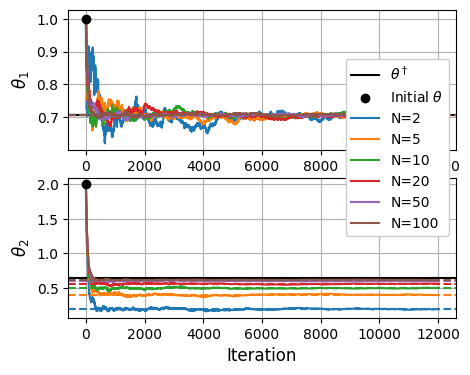

In [56]:
plt.figure(figsize=(5,4))
for i in range(2):
    plt.subplot(2,1,i+1)
    plt.axhline(true_theta_ms[i], color='k', linestyle='-', label=fr'$\theta^\dagger$')
    plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
    for j, sample_size in enumerate(sample_size_set):
        theta_ms_trj = theta_ms_trj_set[str(sample_size)]
        theta_ms_emp_sol = theta_ms_emp_sol_set[str(sample_size)]
        plt.plot(theta_ms_trj[:,i], label=fr'N={sample_size}')
        plt.axhline(theta_ms_emp_sol[i], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
    plt.grid()
    
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel(fr'$\theta_{i+1}$', fontsize=12)
    if i == 1:
        plt.legend(loc='upper right', framealpha=1.0, bbox_to_anchor=(1.0, 1.9))
# plt.savefig(f'./fig_sgd_gaussian_misspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

### bias correction

In [24]:
true_theta_exp = 1
mu2 = true_theta_exp / np.sqrt(2)
sigma2_ms_set = np.concatenate([np.linspace(0.25*true_theta_exp*d_infty_misspecified, 2*true_theta_exp*d_infty_misspecified, 200)])
temp_alpha_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
S_grad_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
J_MSa_ms_set = np.empty((len(sigma2_ms_set), len(Nset)))
for i, sigma2 in enumerate(sigma2_ms_set):
    for j, N in enumerate(Nset):
        S_grad = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2, N, m1s=m1s_set[str(N)])
        J_MSa_grad = expected_EW_emp_emp_exponential_gaussian_grad(true_theta_exp, mu2, sigma2, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)])
        temp_alpha = J_MSa_grad[1] / S_grad[1]
        temp_alpha_ms_set[i,j] = temp_alpha
        S_grad_ms_set[i,j] = S_grad[1]
        J_MSa_ms_set[i,j] = J_MSa_grad[1]

sigma2_ms_heu, fval_ms = minimise_alpha_var_misspecified(true_theta_exp, mu2, Nset, m1s_exp_set=b1s_exp_set, m1s_set=m1s_set)
print(sigma2_ms_heu)

temp_alpha_heu_ms_set = np.empty(len(Nset))
for j, N in enumerate(Nset):
    S_grad_heu = expected_self_wasserstein_loss_gaussian_grad(mu2, sigma2_ms_heu, N, m1s=m1s_set[str(N)])
    J_MSa_grad_heu = expected_EW_emp_emp_exponential_gaussian_grad(true_theta_exp, mu2, sigma2_ms_heu, N, m1s_exp=b1s_exp_set[str(N)], m1s=m1s_set[str(N)])
    temp_alpha_heu_ms_set[j] = J_MSa_grad_heu[1] / S_grad_heu[1]
alpha_ms_heu = np.mean(temp_alpha_heu_ms_set)
print(alpha_ms_heu), temp_alpha_heu_ms_set

0.6366578912682864
0.523706051132752


(None,
 array([0.51273101, 0.52110565, 0.52561508, 0.52823846, 0.53082868,
        0.52973364, 0.52442545, 0.51697044]))

In [52]:
np.random.seed(0)
true_theta_exp = 1
theta0 = np.array([1., 2.])
distr = 'exponential'
alpha = alpha_ms_heu
# alpha = 0.34589757686787065
# alpha = 0.31578873131757146
# alpha = 0.5
print(alpha)
n_iter, eta0, gamma = 12000, 0.01, 0.0025

theta_ms_debias_trj_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_ms_debias_trj = sgd_empirical_sqW2loss_gaussian_misspecified(theta0, true_theta_exp, sample_size, alpha, n_iter, eta0, gamma, distr=distr)
    theta_ms_debias_trj_set[str(sample_size)] = theta_ms_debias_trj

0.523706051132752
0 2
1 5
2 10
3 20
4 50
5 100


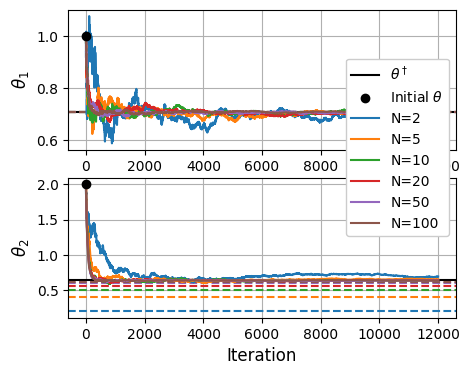

In [57]:
plt.figure(figsize=(5,4))
for i in range(2):
    plt.subplot(2,1,i+1)
    plt.axhline(true_theta_ms[i], color='k', linestyle='-', label=fr'$\theta^\dagger$')
    plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
    for j, sample_size in enumerate(sample_size_set):
        theta_ms_debias_trj = theta_ms_debias_trj_set[str(sample_size)]
        theta_ms_emp_sol = theta_ms_emp_sol_set[str(sample_size)]
        plt.plot(theta_ms_debias_trj[:,i], label=fr'N={sample_size}', zorder=10)
        plt.axhline(theta_ms_emp_sol[i], color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\theta_{i+1}$ (N={sample_size})')
    plt.grid()
    
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel(fr'$\theta_{i+1}$', fontsize=12)
    if i == 1:
        plt.legend(loc='upper right', framealpha=1.0, bbox_to_anchor=(1.0, 1.9))
# plt.savefig(f'./fig_sgd_gaussian_misspecified_bias_corrected.pdf', format='pdf', bbox_inches="tight", dpi=300)